# Quantum Computing Lab - Assignment 4
## Mrudula A Mahindrakar
### EE25S011

In [5]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit import quantum_info as qi
from qiskit.quantum_info import Operator
from qiskit.circuit.library import UnitaryGate
from qiskit import transpile
from qiskit_aer import AerSimulator, Aer
from qiskit_aer.noise import NoiseModel, pauli_error
from qiskit.circuit.library import QFT
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime.fake_provider import FakeGuadalupeV2

from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

import numpy as np
from fractions import Fraction
import math
import warnings
from IPython.display import display
import random
from scipy.linalg import expm

# Problem 1: Order Finding Algorithm

Order Finding
Given: x^r modN = 1

The smallest positive integer r satisfying this is called the order of x modulo N.

This is implemented using:
- Phase Estimation
- Unitary: U∣y⟩ = ∣xy mod N⟩

In [2]:
# Problem 1(a)(i): Choose N = 15 and x = 2, 4, 7, 8, 11, 13. What is the value of r for which x^r mod N = 1

def classical_order(x, N):
    """
    Returns smallest r such that x^r mod N = 1
    """
    if np.gcd(x, N) != 1:
        return None  # Order only exists if x and N are coprime
    
    r = 1
    val = x % N
    while val != 1:
        val = (val * x) % N
        r += 1
    return r

N = 15
x_values = [2, 4, 7, 8, 11, 13]

for x in x_values:
    r = classical_order(x, N)
    print(f"x={x}, r={r}")

x=2, r=4
x=4, r=2
x=7, r=4
x=8, r=4
x=11, r=2
x=13, r=4


In [3]:
# Problem 1(a)(ii)

def modular_multiplication_operator(x, N, n_qubits):

    dim = 2**n_qubits
    U = np.zeros((dim, dim))
    
    for y in range(dim):
        if y < N:
            target = (x * y) % N
            U[target, y] = 1
        else:
            # For states >= N,
            U[y, y] = 1
            
    return Operator(U)

### Problem 1(a)(iii) : What is the circuit depth in all-to-all qubit couplings?

Let $L = [log_2(N)]$ be the number of qubits required to represent N. For $N=15$, the number of qubits required for the work register is **$L = \lceil \log_2(15) \rceil = 4$**. 

According to Nielsen & Chuang, the modular exponentiation stepfor $x \cdot y \pmod N$ has a depth of $O(L^2)$. Since this involves $2L$ (or $t$) sequential multiplications, the total theoretical depth is **$O(L^3)$**.

In this practical implementation, because we define $U$ as a high-level matrix, the simulator treats the Modular Unitary ($U$) as a single functional block with a depth of **1**. The depth of a standard n-bit QFT is O(n).
Total depth of the unitary including the Inverse QFT will be of the order O(L).

In [4]:
# Problem 1(a)(iv)

def order_finding_circuit(x, N, t, n):
    # t: counting qubits 
    # n: work qubits 
    qc = QuantumCircuit(t + n, t)
    
    qc.h(range(t))
    
    qc.x(t) 
    
    # Controlled-U^(2^k)
    for k in range(t):
        # x^(2^k) mod N 
        x_pow = pow(x, 2**k, N)
        U_op = modular_multiplication_operator(x_pow, N, n)
        ctrl_U = UnitaryGate(U_op.data, label="U").control(1)
        qc.append(ctrl_U, [k] + list(range(t, t + n)))
    
    # Inverse QFT
    qc.append(QFT(t).inverse(), range(t))
    
    # Measurement
    qc.measure(range(t), range(t))
    
    return qc

### Problem 1(a)(v)
QPE starts with a known eigenvector $|u\rangle$ of the unitary operator $U$. The goal is to find the phase $\phi$ such that $U|u\rangle = e^{2\pi i \phi}|u\rangle$. The output is directly interpreted as a binary approximation of the phase.

Order-Finding: We do not know the eigenstates of the modular multiplication operator $U$. Instead, we initialize the target register to the state $|1\rangle$.  The state $|1\rangle$ is actually a **uniform superposition** of all $r$ possible eigenstates of $U$,  $$|1\rangle = \frac{1}{\sqrt{r}} \sum_{s=0}^{r-1} |u_s\rangle$$  This causes the measurement to collapse into one of $r$ possible phases ($\frac{s}{r}$) with equal probability. The measured phase is just the first step. We must apply the **Continued Fractions Algorithm** to the measured value to extract the integer denominator, which is our candidate for the order $r$.


In [5]:
# Problem 1(a)(vi) Post processing continued fractions algorithm 

def order_r(counts,t,N,x):
    sorted_counts = sorted(counts.items(), key=lambda item: item[1], reverse=True)
    for bitstring, _ in sorted_counts:
        m = int(bitstring, 2)
        if m == 0: continue
        phase = m / (2**t)
        
        # continued fractions
        frac = Fraction(phase).limit_denominator(N)
        r = frac.denominator
        if pow(int(x), int(r), int(N)) == 1:
            return m, phase, frac, r

N = 15
x_values = [2, 4, 7, 8, 11, 13]
t = 8  # Precision qubits
n = 4  # Work qubits (2^4 > 15)

warnings.filterwarnings("ignore", category=DeprecationWarning)

print(f"{'x':<5} | {'Measured m':<12} | {'Phase (m/2^t)':<15} | {'Fraction':<10} | {'Order r':<8}")
print("-" * 60)

for x in x_values:
    qc = order_finding_circuit(x, N, t, n)
    qc_compiled = transpile(qc, AerSimulator())
    job = AerSimulator().run(qc_compiled, shots=1024)
    counts = job.result().get_counts()

    m, phase, frac, r = order_r(counts,t,N,x)
    # Verification
    #if pow(x, r, N) == 1:
    print(f"{x:<5} | {m:<12} | {phase:<15.4f} | {str(frac):<10} | {r:<8}")

x     | Measured m   | Phase (m/2^t)   | Fraction   | Order r 
------------------------------------------------------------
2     | 64           | 0.2500          | 1/4        | 4       
4     | 128          | 0.5000          | 1/2        | 2       
7     | 192          | 0.7500          | 3/4        | 4       
8     | 192          | 0.7500          | 3/4        | 4       
11    | 128          | 0.5000          | 1/2        | 2       
13    | 192          | 0.7500          | 3/4        | 4       


### Summary of Order-Finding Results 

example, $N=15, x=7$

Using the Quantum Order-Finding algorithm with $t=8$ counting qubits, we successfully measured the periodicity of $f(j) = 7^j \pmod{15}$.

With $2^t = 256$ possible states, the peaks correspond to the phases $\phi = \frac{s}{r}$, where $r$ is the order.

| Measured ($y$) | Phase ($y/256$) | Fraction |  $r$ | Result |
| :--- | :--- | :--- | :--- | :--- |
| **0** | 0.000 | 0/1 | 1 | Trivial |
| **64** | 0.250 | 1/4 | **4** | **Success** |
| **128** | 0.500 | 1/2 | 2 | Partial (Factor of $r$) |
| **192** | 0.750 | 3/4 | **4** | **Success** |

The algorithm successfully identified the smallest integer $r=4$ such that, $$7^4 \equiv 2401 \equiv 1 \pmod{15}$$

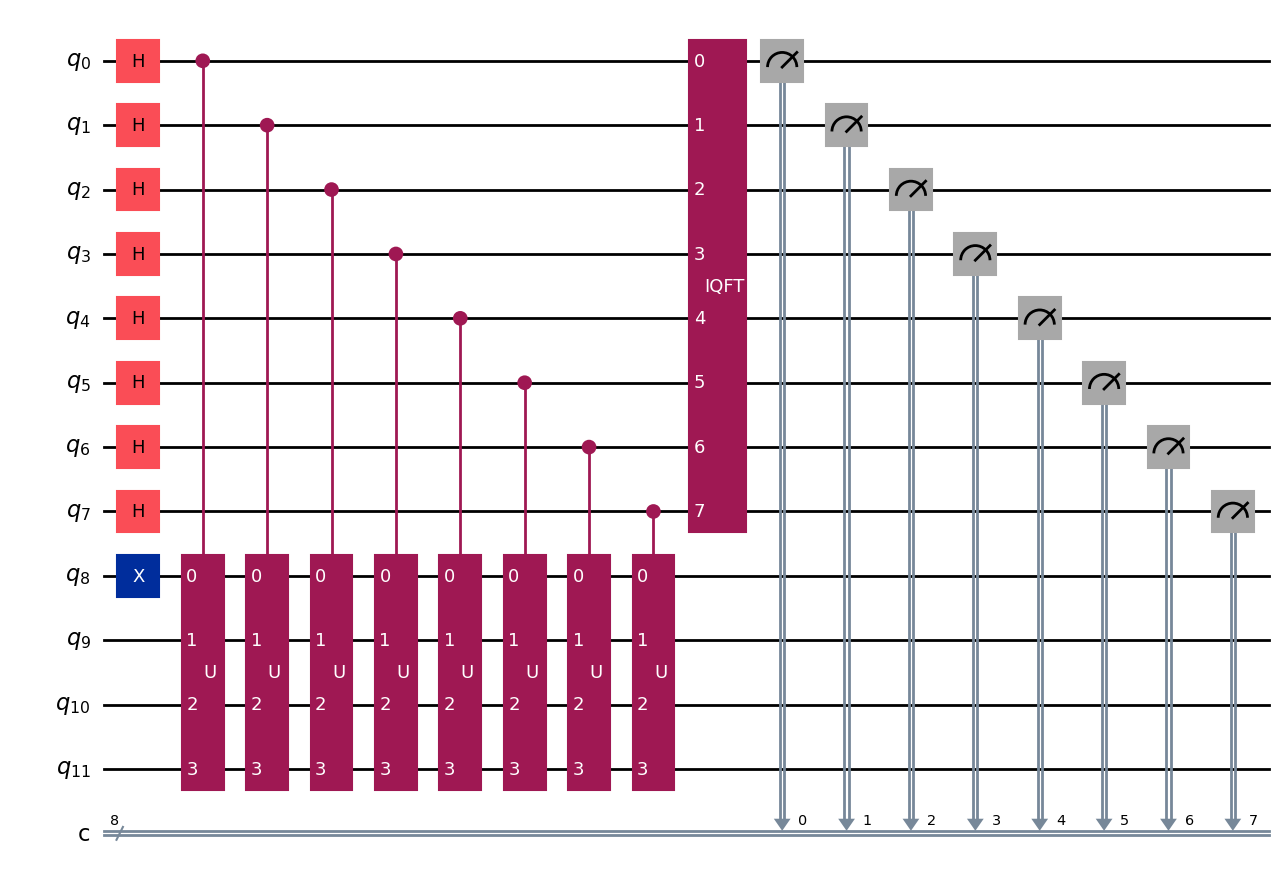

In [6]:
qc.draw(output='mpl', idle_wires=False)

In [7]:
# problem 1(a)(vii) circuit depth 
print(f"{'x':<10} | {'Depth':<20}")
print("-"*20)
for x in x_values:
    qc = order_finding_circuit(x, N, t, n)
    qc_t = transpile(qc, AerSimulator(), optimization_level=1)
    print(f"{x:<10} | {qc_t.depth():<20}")

x          | Depth               
--------------------
2          | 927                 
4          | 462                 
7          | 925                 
8          | 925                 
11         | 465                 
13         | 928                 


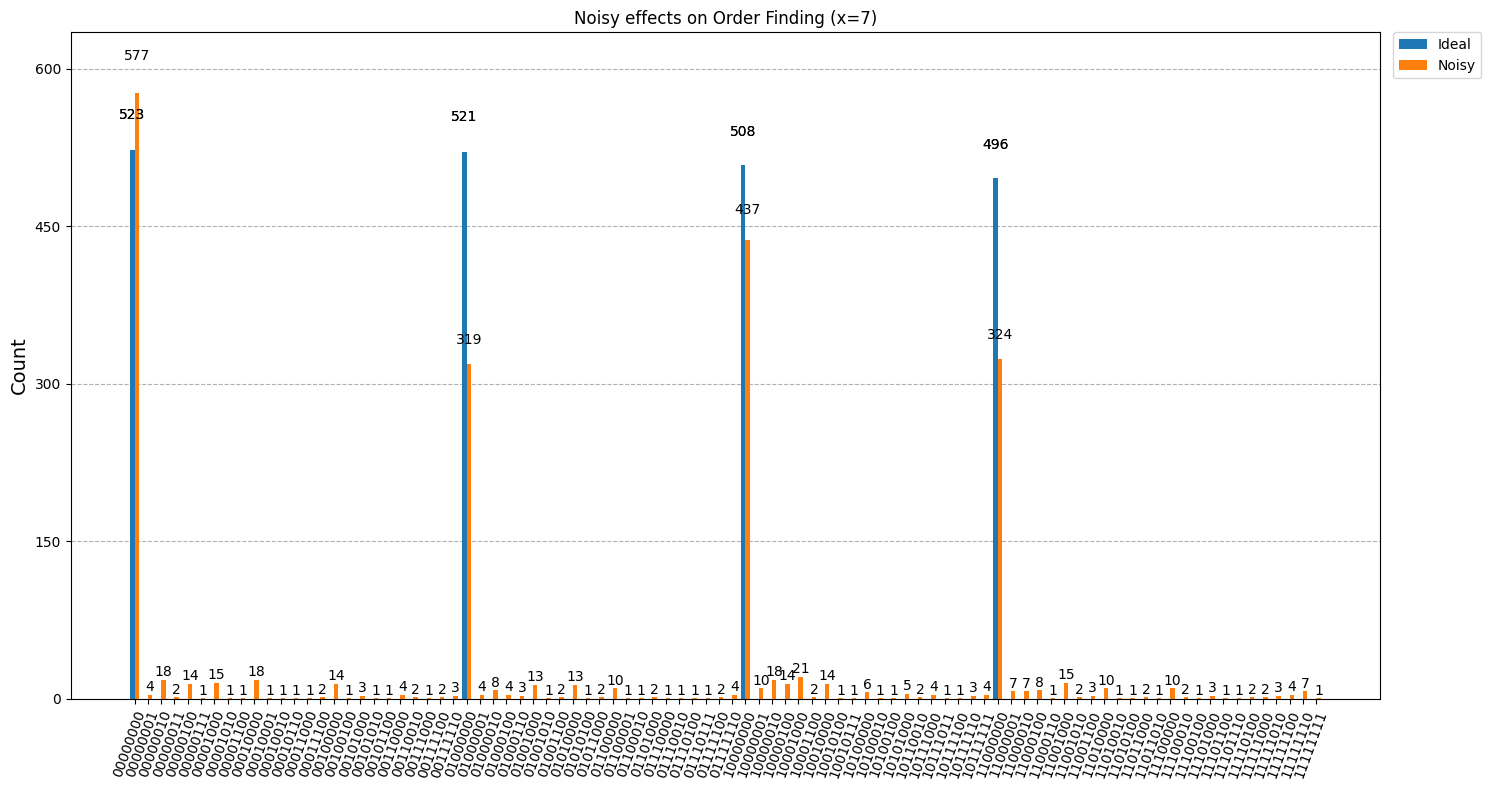

In [8]:
# Problem 1(a)(viii) Noisy vs Noiseless simulator

def Noisy_counts(x, N, t, n, shots=2048):
    ideal_sim = AerSimulator()
    fake_backend = FakeGuadalupeV2()
    noise_model = NoiseModel.from_backend(fake_backend)
    noisy_sim = AerSimulator(noise_model=noise_model)
    
    qc = order_finding_circuit(x, N, t, n)
    
    qc_ideal = transpile(qc, ideal_sim, optimization_level=1)
    result_ideal = ideal_sim.run(qc_ideal, shots=shots).result() 
    counts_ideal = result_ideal.get_counts()
    
    qc_noisy = transpile(qc, noisy_sim, optimization_level=1)
    result_noisy = noisy_sim.run(qc_noisy, shots=shots).result()  #
    counts_noisy = result_noisy.get_counts()

    return counts_ideal, counts_noisy

x_test = 7
N = 15
n = 4
t = 8
counts_ideal, counts_noisy =  Noisy_counts(x_test, N, t, n, shots=2048)

plot_histogram([counts_ideal, counts_noisy], 
               legend=["Ideal", "Noisy"], 
               figsize=(15, 8),
               title=f"Noisy effects on Order Finding (x={x_test})")

In [9]:
# Problem 1(a)(ix) Factoring N = 15.

def classical_post_processing(x, r, N):
    val = pow(x, r // 2, N)
    
    factor1 = math.gcd(val - 1, N)
    factor2 = math.gcd(val + 1, N)
    
    return factor1, factor2

N = 15
x = 7
r = 4

factors = classical_post_processing(x, r, N)
if factors:
    print(f"The factors of {N} are {factors[0]} and {factors[1]}.")

The factors of 15 are 3 and 5.


In [ ]:
# Problem 1(b) Factoring N in {21, 33, 35, 65}

N_list = [21, 33, 35, 65]

print(f"{'N':<5} | {'x':<3} | {'r (Ideal)':<10} | {'r (Noisy)':<10} | {'Factors (Ideal)':<18} | {'Factors (Noisy)':<18}")
print("-" * 85)

for N in N_list:
    # Randomized coprime x
    x = random.randint(2, N - 1)
    while math.gcd(x, N) != 1:
        x = random.randint(2, N - 1)
    
    n = N.bit_length()
    t = n + 3 
    print(f"Running N={N}, x={x} using t={t}, n={n} (Total qubits: {t+n})")

    counts_ideal, counts_noisy = Noisy_counts(x, N, t, n, shots=512)

    res_i = order_r(counts_ideal, t, N, x)
    res_n = order_r(counts_noisy, t, N, x)

    r_i = res_i[3] if res_i else None
    r_n = res_n[3] if res_n else None

    factors_i = classical_post_processing(x, r_i, N) if (r_i and r_i % 2 == 0) else "Failed"
    factors_n = classical_post_processing(x, r_n, N) if (r_n and r_n % 2 == 0) else "Failed"

    print(f"{N:<5} | {x:<3} | {str(r_i):<10} | {str(r_n):<10} | {str(factors_i):<18} | {str(factors_n):<18}")

N     | x   | r (Ideal)  | r (Noisy)  | Factors (Ideal)    | Factors (Noisy)   
-------------------------------------------------------------------------------------
Running N=21, x=19 using t=8, n=5 (Total qubits: 13)
21    | 19  | 6          | 18         | (3, 7)             | (3, 7)            
Running N=33, x=26 using t=9, n=6 (Total qubits: 15)
33    | 26  | 10         | 30         | (11, 3)            | (11, 3)           
Running N=35, x=3 using t=9, n=6 (Total qubits: 15)
35    | 3   | 12         | 24         | (7, 5)             | (35, 1)           
Running N=65, x=57 using t=10, n=7 (Total qubits: 17)


# Problem 2: Other applications of QPE & QFT

Here we will explore how to use the QPE in determining the eigenvalues of a Hamiltonian.

Consider the following two-particle Hamiltonian
$H = H_1 + H_2$ where $H_1 = −0.01I4 − 0.005(ZI + IZ) and H_2 = −0.01(Y \oplus Y + X \oplus X)$

* Evaluate the eigenvalues and the eigenvectors of this Hamiltonian.
* Design the circuit for $U = e^{−iH}$. Use one of the eigenvectors of H to evaluate its eigenvalues using the QPE circuit.


Given the Hamiltonian $H = H_1 + H_2$:
$H_1 = -0.01I_4 - 0.005(Z \otimes I + I \otimes Z)$
$H_2 = -0.01(Y \otimes Y + X \otimes X)$

In the computational basis $\{|00\rangle, |01\rangle, |10\rangle, |11\rangle\}$, the operators are:
- $I_4 = \text{diag}(1, 1, 1, 1)$
- $Z \otimes I = \text{diag}(1, 1, -1, -1)$
- $I \otimes Z = \text{diag}(1, -1, 1, -1)$

Combining these for $H_1$:
$$H_1 = \begin{pmatrix} -0.02 & 0 & 0 & 0 \\ 0 & -0.01 & 0 & 0 \\ 0 & 0 & -0.01 & 0 \\ 0 & 0 & 0 & 0 \end{pmatrix}$$

For $H_2$, using $X = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$ and $Y = \begin{pmatrix} 0 & -i \\ i & 0 \end{pmatrix}$:
- $X \otimes X$ swaps $|01\rangle \leftrightarrow |10\rangle$ and $|00\rangle \leftrightarrow |11\rangle$.
- $Y \otimes Y$ does the same but with a phase shift.
- The sum $X \otimes X + Y \otimes Y$ only acts on the subspace $\{|01\rangle, |10\rangle\}$.

$$H_2 = \begin{pmatrix} 0 & 0 & 0 & 0 \\ 0 & 0 & -0.02 & 0 \\ 0 & -0.02 & 0 & 0 \\ 0 & 0 & 0 & 0 \end{pmatrix}$$

$$H = H_1 + H_2 = \begin{pmatrix} -0.02 & 0 & 0 & 0 \\ 0 & -0.01 & -0.02 & 0 \\ 0 & -0.02 & -0.01 & 0 \\ 0 & 0 & 0 & 0 \end{pmatrix}$$

The eigenvalues $\lambda$ and eigenvectors $|\psi\rangle$ are:
1. $\lambda_1 = -0.02$, $|\psi_1\rangle = |00\rangle$
2. $\lambda_2 = 0$, $|\psi_2\rangle = |11\rangle$
3. $\lambda_3 = -0.03$, $|\psi_3\rangle = \frac{1}{\sqrt{2}}(|01\rangle + |10\rangle)$ (Symmetric/Triplet)
4. $\lambda_4 = 0.01$, $|\psi_4\rangle = \frac{1}{\sqrt{2}}(|01\rangle - |10\rangle)$ (Anti-symmetric/Singlet)

To estimate the eigenvalue of $U = e^{-iH}$, we use the QPE algorithm. 
The phase $\phi$ estimated by QPE relates to the eigenvalue $E$ as:
$$e^{i 2\pi \phi} = e^{-i E} \implies \phi = -\frac{E}{2\pi}$$

In [13]:
# Problem 2
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Pauli Matrices
I = np.eye(2)
X = np.array([[0, 1], [1, 0]])
Y = np.array([[0, -1j], [1j, 0]])
Z = np.array([[1, 0], [0, -1]])

H1 = -0.01 * np.eye(4) - 0.005 * (np.kron(Z, I) + np.kron(I, Z))
H2 = -0.01 * (np.kron(Y, Y) + np.kron(X, X))
H = H1 + H2

eigenvalues, eigenvectors = np.linalg.eigh(H)
print("Eigenvalues:", eigenvalues)

#  U = exp(-iH)
U_matrix = Operator(expm(-1j * H))

def qpe(idx, n=8):
    q1 = QuantumRegister(n, 'eval')
    q2 = QuantumRegister(2, 'state')
    c = ClassicalRegister(n, 'res')
    qc = QuantumCircuit(q1, q2, c)

    # use |00> at idx 0
    state_to_prepare = eigenvectors[:, idx]
    qc.prepare_state(state_to_prepare, q2)

    qc.h(q1)

    for i in range(n):
        # controlled U^(2^i)
        U_power = U_matrix.power(2**i).to_instruction()
        U_power.name = f"U^2^{i}"
        ctrl_U = U_power.control(1)
        qc.append(ctrl_U, [q1[i]] + q2[:])

    qc.append(QFT(n).inverse(), q1)

    qc.measure(q1, c)
    return qc

n = 10
qc = qpe(idx=0, n=n)

simulator = AerSimulator()
t_qc = transpile(qc, simulator)
result = simulator.run(t_qc, shots=1024).result()
counts = result.get_counts()

highest_prob_phase = int(max(counts, key=counts.get), 2) / (2**n)
# energy E = -phase * 2pi
estimated_energy = -highest_prob_phase * 2 * np.pi

print(f"Measured Phase: {highest_prob_phase}")
print(f"Estimated Energy: {estimated_energy:.5f}")
print(f"Actual Energy: {eigenvalues[0]:.5f}")

Eigenvalues: [-0.03 -0.02  0.    0.01]
Measured Phase: 0.0048828125
Estimated Energy: -0.03068
Actual Energy: -0.03000
